# LoRA for Stable Diffusion

Ноутбук для того, чтобы познакомиться, как обучить свой LoRA-adapter для `stable diffusion` модели

In [ ]:
# !pip install -q diffusers
# !pip install -q datasets
# !pip install -q transformers
# !pip install -q accelerate

In [2]:
import os

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [ ]:
import datasets
import torch

from PIL import Image
from pathlib import Path
from tqdm.notebook import tqdm

from safetensors.torch import save_file, load_file
from torch.utils.data import DataLoader
from torchvision.transforms.functional import pad, to_pil_image, to_tensor

from diffusers.utils import make_image_grid
from diffusers import StableDiffusionXLPipeline, StableDiffusionPipeline
from diffusers import AutoencoderKL

### 1. Dataset Preparation.

1. Загрузим датасет
1. Визуализируем примеры
1. Подготовим функции препроцессинга
1. Обернем в `torch.utils.Dataset` (либо `datasets` стиль, как вам больше нравится)

In [4]:
hfdataset = datasets.load_dataset("multimodalart/1920-raider-waite-tarot-public-domain")

Resolving data files:   0%|          | 0/79 [00:00<?, ?it/s]

In [5]:
# визуализируйте несколько примеров
# hint: make_image_grid

In [ ]:
def resize_image_to(image: Image.Image, max_to: int = 512) -> Image.Image:
    # Функция принимает изображение и ресайзит так, чтобы максимальная сторона равнялась max_to
    ...

**P.s.** если хотите, можете переделать из формата `torch.utils.data.Dataset` в формат hf-dataset (надо будет сделать аналогичные `map` преобразования)

In [ ]:
MAX_SIDE = 512

class ImgDataset(torch.utils.data.Dataset):
    def __init__(self, dataset):
        super().__init__()
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    @staticmethod
    def _prepare_tensor_and_pad(image: Image.Image) -> torch.Tensor:
        # Метод делает следующее:
        # 1. превращает изображение в тензор [0..1] (chw-формат)
        # 2. падит изображение до размера MAX_SIDExMAX_SIDE (белым цветом). Hint: pad
        ...
        
    def __getitem__(self, item):
        d = self.dataset[item]

        pil_image = resize_image_to(d['image'])
        pt_image = self._prepare_tensor_and_pad(pil_image)

        return {
            "image": pt_image,
            "caption": d["caption"],
            "index": item,  # пригодится для кеша
        }

a trtcrd of a woman wearing a crown sitting on an adorned chair, holding a sword, "queen of swords"


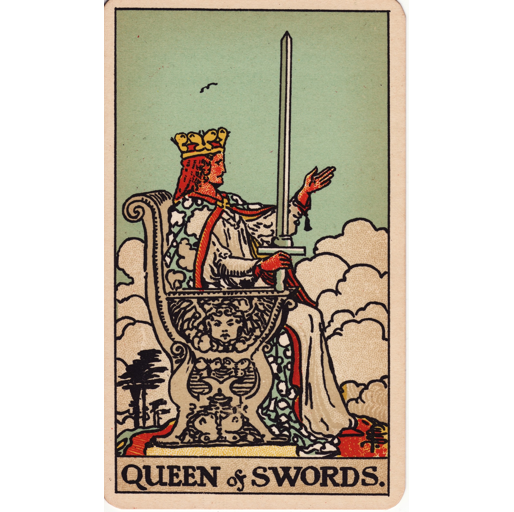

In [8]:
dataset = ImgDataset(hfdataset["train"])

ind = 0
item = dataset[ind]

print(item["caption"])
to_pil_image(item["image"])

### 2. Загрузка всех необходимых компонент

**P.s.** Вы можете сделать задачу с использованием `StableDiffusionXLPipeline`

`(StableDiffusionXLPipeline.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0")`

Но тогда придется самостоятельно (и внимательно) адаптировать код

- например, `sdxl` имеет 2 текстовых энкодера

In [9]:
dtype = torch.float16
cuda_device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
assert cuda_device == torch.device("cuda:0")

In [10]:
repo_id = "stable-diffusion-v1-5/stable-diffusion-v1-5"
pipeline = StableDiffusionPipeline.from_pretrained(repo_id, torch_dtype=dtype)
# pipeline = StableDiffusionXLPipeline.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0", torch_dtype=dtype)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


In [11]:
# мы отдельно вытащим все компоненты, а сам pipeline удалим, чтобы удобнее и проще было следить за выделяемыми ресурсами

scheduler = pipeline.scheduler
text_encoder = pipeline.text_encoder
tokenizer = pipeline.tokenizer
unet = pipeline.unet
vae = pipeline.vae
image_processor = pipeline.image_processor

# сами компоненты не удаляются, только эта ссылка
del pipeline

### Кеширование латентов

Для того, чтобы не тратить гпу память в пустую (и для более эффективного обучения) всегда стоит стараться кешировать латенты

- `vae` латенты
- `text_encoder` латенты -- если не обучаем текстовый энкодер

In [ ]:
@torch.inference_mode()
def encode_image(image: torch.Tensor) -> torch.Tensor:
    # 1. Препроцессинг тензора (hint: image_processor)
    # 2. Кодирование с vae
    # 3. *Важно* результат не забудьте домножить на vae.config.scaling_factor 
    # https://github.com/huggingface/diffusers/issues/437
    ...

@torch.inference_mode()
def decode_image(tensor: torch.Tensor) -> Image.Image:
    # для визуализации
    def normalize(tensor):
        return (tensor - tensor.min()) / (tensor.max() - tensor.min())
    tensor = normalize(vae.decode(tensor.to(vae.device, vae.dtype) / vae.config.scaling_factor).sample)
    return to_pil_image(tensor.squeeze(0))

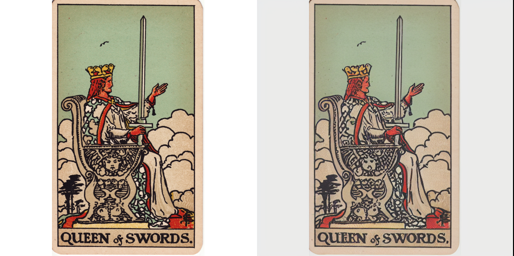

In [13]:
vae = vae.to(cuda_device, dtype=torch.float32)  # note: dtype -- fp32

# Проверка работоспособности

item = dataset[0]
image = item["image"]
decoded_image = decode_image(encode_image(image))
image_grid = make_image_grid([to_pil_image(image), decoded_image], rows=1, cols=2)
image_grid.resize((image_grid.size[0] // 2, image_grid.size[1] // 2))

In [14]:
@torch.inference_mode()
def encode_prompt(prompt: str) -> torch.Tensor:
    text_inputs = tokenizer(
        prompt,
        padding="max_length",
        max_length=tokenizer.model_max_length,
        truncation=True,
        return_tensors="pt",
    )
    text_input_ids = text_inputs.input_ids

    prompt_embeds = text_encoder(
        text_input_ids.to(text_encoder.device),
        attention_mask=None
    )
    return prompt_embeds[0]

In [15]:
text_encoder = text_encoder.to(cuda_device, dtype=dtype)

In [16]:
# проверка работы

encoded_prompt = encode_prompt(dataset[0]['caption'])

assert encoded_prompt.shape == (1, 77, 768)

Сразу зафиксируем будем обучать текстовый энкодер или нет. Надо знать, чтобы понимать, что стоит кешировать

In [17]:
TRAIN_TEXT_ENCODER = True

In [18]:
def cache(dataset: ImgDataset, cache_prompts: bool = False, save_path: Path = Path("./.data_cache/")):
    save_path.mkdir(exist_ok=True, parents=True)

    for item in tqdm(dataset, total=len(dataset)):
        image = item['image']
        prompt = item['caption']

        encoded_prompt = None
        encoded_image = encode_image(image).cpu()
        result = {
            "image": encoded_image,
        }
        if cache_prompts:
            encoded_prompt = encode_prompt(prompt).cpu()
            result["prompt"] = encoded_prompt

        filename = f"{item['index']}.safetensors"
        save_file(result, save_path / filename)

In [19]:
cache_path = Path("./.data_cache")

cache(dataset, cache_prompts=not TRAIN_TEXT_ENCODER, save_path=cache_path)

  0%|          | 0/78 [00:00<?, ?it/s]

In [20]:
# Проверяем, что можем достать кеш
ind = 1
encoded_image_1 = encode_image(dataset[ind]["image"]).cpu()

cached_file = load_file(cache_path / f"{ind}.safetensors")
encoded_image_2 = cached_file["image"]

assert torch.allclose(encoded_image_1, encoded_image_2)

In [21]:
# теперь нам больше не понадобятся vae (и возможно text_encoder)
# можем освободить память

del vae
if not TRAIN_TEXT_ENCODER:
    del text_encoder

torch.cuda.empty_cache()

### Подготовка LoRA модулей

Мы не будем пользоваться `Peft` библиотекой, а будем сами писать свои модули, используя голый `torch`

In [ ]:
from torch import nn
from diffusers.models.attention_processor import Attention
import math

class LoRALinear(nn.Module):
    def __init__(self, wrapped: nn.Linear, rank: int = 4, alpha: int = 1):
        super().__init__()
        self.wrapped = wrapped
        self.rank = rank
        self.alpha = alpha

        in_features = wrapped.in_features
        out_features = wrapped.out_features

        self.lora_down = nn.Linear(in_features, rank, bias=False)
        self.lora_up = nn.Linear(rank, out_features, bias=False)

        # https://github.com/microsoft/LoRA/blob/c4593f060e6a368d7bb5af5273b8e42810cdef90/loralib/layers.py#L124
        nn.init.kaiming_uniform_(self.lora_down.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_up.weight)

        for p in self.wrapped.parameters():
            p.requires_grad_(False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        ...

In [ ]:
def add_lora_to_unet_attention(unet: nn.Module, rank: int = 4, alpha: int = 1) -> list[nn.Module]:
    # Пройдитесь по unet и замените q и v в cross-attention
    # Вернуть все модули, где будет происходить обучение
    # hint 1: unet.named_modules
    # hint 2: надо найти .to_q и .to_v в Attention
    ...

In [24]:
def add_lora_to_text_encoder(text_encoder: nn.Module, rank: int = 4, alpha: int = 1) -> list[nn.Module]:
    # отдохните, тут все реализовано
    trainable_modules = []

    encoder = text_encoder.text_model.encoder
    for layer in encoder.layers:
        attn = layer.self_attn
        attn.q_proj = LoRALinear(attn.q_proj, rank=rank, alpha=alpha)
        attn.v_proj = LoRALinear(attn.v_proj, rank=rank, alpha=alpha)
        trainable_modules.extend([
                attn.q_proj.lora_down,
                attn.q_proj.lora_up,
                attn.v_proj.lora_down,
                attn.v_proj.lora_up
            ])
    return trainable_modules

### Подготовка моделей

In [25]:
# для удобства
if not TRAIN_TEXT_ENCODER:
    text_encoder = nn.Identity()

unet = unet.to(cuda_device, dtype=dtype)

unet.requires_grad_(False)
text_encoder.requires_grad_(False);

In [26]:
ALPHA = 1
RANK = 4

# p.s. модели в fp16, однако lora fp32
# p.s. осторожно, функции не идемпотентны
unet_modules = add_lora_to_unet_attention(unet, rank=RANK, alpha=ALPHA)
text_encoder_modules = add_lora_to_text_encoder(text_encoder, rank=RANK, alpha=ALPHA) if TRAIN_TEXT_ENCODER else []

unet.to(cuda_device)
text_encoder.to(cuda_device);

### Готовим все для обучения

In [27]:
from dataclasses import dataclass

@dataclass
class TrainConfig:
    batch_size: int = 1
    num_epochs: int = 10
    lr: float = 1e-4
    output_dir: str = "./lora_out"
    max_train_steps: int = 1000
    gradient_accumulation_steps: int = 1

cfg = TrainConfig()

In [28]:
# готовим оптимайзер

train_params = []
for m in unet_modules:
    train_params.extend([p for p in m.parameters() if p.requires_grad])

for m in text_encoder_modules:
    train_params.extend([p for p in m.parameters() if p.requires_grad])

optimizer = torch.optim.AdamW(train_params, lr=cfg.lr)

In [29]:
dataloader = DataLoader(dataset, batch_size=cfg.batch_size, shuffle=True)

noise_scheduler = scheduler

unet.train()
text_encoder.train();

In [30]:
# safe-check: проверяем, что числа сходятся

print(sum((x.numel() for p in text_encoder_modules for x in p.parameters()  if x.requires_grad)))
print(sum((x.numel() for x in text_encoder.parameters() if x.requires_grad)))
print(sum((x.numel() for x in text_encoder.parameters())))

print("-"*100)

print(sum((x.numel() for p in unet_modules for x in p.parameters()  if x.requires_grad)))
print(sum((x.numel() for x in unet.parameters() if x.requires_grad)))

print(sum((x.numel() for x in unet.parameters())))

print("-"*100)

print(sum((x.numel() for x in train_params)))
print(sum((x.numel() for x in unet.parameters() if x.requires_grad)) + sum((x.numel() for x in text_encoder.parameters() if x.requires_grad)))

print("-"*100)

147456
147456
123207936
----------------------------------------------------------------------------------------------------
398592
398592
859919556
----------------------------------------------------------------------------------------------------
546048
546048
----------------------------------------------------------------------------------------------------


In [ ]:
scaler = torch.amp.GradScaler(enabled=True)
global_step = 0

for epoch in range(cfg.num_epochs):
    with tqdm(total=len(dataloader)) as pbar:
        for batch in dataloader:
            if global_step >= cfg.max_train_steps:
                break
    
            optimizer.zero_grad(set_to_none=True)
    
            # https://docs.pytorch.org/docs/stable/amp.html
            with torch.autocast(device_type=str(cuda_device), dtype=dtype, enabled=True):
                # 1. Подготовка данных
                # мы используем bs == 1
                # если больше, то собирать надо по-другому
                cached_file = load_file(cache_path / f"{batch['index'].item()}.safetensors")
                latents = cached_file["image"].to(cuda_device, dtype=unet.dtype)
                prompts = batch["caption"]
                
                if TRAIN_TEXT_ENCODER:
                    text_inputs = tokenizer(
                        prompts,
                        padding="max_length",
                        max_length=tokenizer.model_max_length,
                        truncation=True,
                        return_tensors="pt",
                    )
                    input_ids = text_inputs.input_ids.to(text_encoder.device)
    
                    # тут есть LoRA в text_encoder, поэтому без no_grad
                    encoder_hidden_states = text_encoder(input_ids)[0]
                else:
                    encoder_hidden_states = cached_file["prompt"].to(cuda_device, dtype=dtype)
    
                # 2. Подготовка input модели
                # пригодтовить noise
                # приготовить timesteps (torch.long dtype)
                # приготовить noisy_latents (hint: .add_noise)
                bsz = latents.shape[0]
                ...
    
                # 3. Обучение
                model_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample
                loss = torch.nn.functional.mse_loss(model_pred, noise)
    
            # backward с масштабированием
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
    
            global_step += 1
    
            if global_step % 10 == 0:
                pbar.set_description(f"Epoch {epoch} Step {global_step} Loss {loss.item():.4f}")
            pbar.update(1)

  0%|          | 0/78 [00:00<?, ?it/s]

  0%|          | 0/78 [00:00<?, ?it/s]

  0%|          | 0/78 [00:00<?, ?it/s]

  0%|          | 0/78 [00:00<?, ?it/s]

  0%|          | 0/78 [00:00<?, ?it/s]

  0%|          | 0/78 [00:00<?, ?it/s]

  0%|          | 0/78 [00:00<?, ?it/s]

  0%|          | 0/78 [00:00<?, ?it/s]

  0%|          | 0/78 [00:00<?, ?it/s]

  0%|          | 0/78 [00:00<?, ?it/s]

### Inference

In [ ]:
prompt = "a trtcrd of a dog"

In [ ]:
# hint: можно заново собрать StableDiffusionPipeline
...

---

In [ ]:
# ps: сравните с оригинальным пайплайном